<a href="https://colab.research.google.com/github/ProgramasParaFisicaDeParticulas/blindsampleanalysiswithcsv6-SMBAXIN/blob/main/Sample_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#panda nos permite manipular el archivo csv https://pandas.pydata.org
import pandas as pd
#numpy nos permite hacer operaciones usando vectores https://numpy.org
import numpy as np
#plotly nos permite crear graficas interactivas https://plotly.com/python/
import plotly.express as px
%matplotlib inline

!git clone https://github.com/ProgramasParaFisicaDeParticulas/blindsampleanalysiswithcsv6-SMBAXIN.git

Cloning into 'blindsampleanalysiswithcsv6-SMBAXIN'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 1.01 MiB | 6.59 MiB/s, done.


In [ ]:
carpeta = pd.read_csv('/content/blindsampleanalysiswithcsv6-SMBAXIN/Sample6.csv')
carpeta.head()

,Run,Event,type1,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,type2,E2,px2,py2,pz2,pt2,eta2,phi2,Q2
0,165617,75100943,G,6.2039,-4.2666,0.4565,-4.4793,4.2910,-0.9121,3.0350,-1,G,9.6690,7.2740,-2.8211,-5.7104,7.8019,-0.6786,-0.3700,1
1,165617,75587682,G,19.2892,-4.2121,-0.6516,18.8121,4.2622,2.1905,-2.9881,-1,G,9.8244,4.3439,-0.4735,8.7985,4.3697,1.4497,-0.1086,1
2,165617,75167029,G,9.7583,2.3903,-3.7824,8.6715,4.4744,1.4156,-1.0072,-1,G,13.5684,-3.3975,5.1910,12.0665,6.2039,1.4187,2.1503,1
3,165617,75281957,G,9.6365,1.6516,-5.4313,7.7862,5.6769,1.1213,-1.2756,1,G,7.0263,-1.6449,4.4418,5.1887,4.7366,0.9473,1.9255,-1
4,165617,75393376,G,6.0112,3.3614,2.8883,4.0598,4.4318,0.8208,0.7098,-1,G,7.7557,-5.0416,-3.0126,5.0642,5.8731,0.7806,-2.6030,1


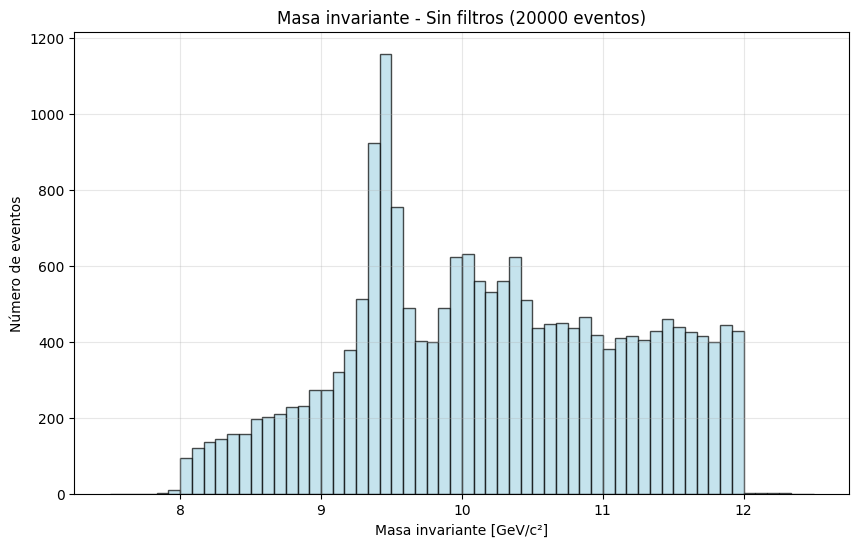

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Calcular masa invariante (con pt, eta, phi)
carpeta['M'] = np.sqrt( 2 * carpeta['pt1'] * carpeta['pt2'] *
                         ( np.cosh(carpeta['eta1'] - carpeta['eta2']) -
                           np.cos(carpeta['phi1'] - carpeta['phi2']) ) )

# Graficar histograma de masa invariante (sin filtros)
plt.figure(figsize=(10, 6))
plt.hist(carpeta['M'], bins=60, range=(7.5, 12.5), color='lightblue', edgecolor='black', alpha=0.7)
plt.xlabel('Masa invariante [GeV/c²]')
plt.ylabel('Número de eventos')
plt.title(f'Masa invariante - Sin filtros ({len(carpeta)} eventos)')
plt.grid(True, alpha=0.3)
plt.show()

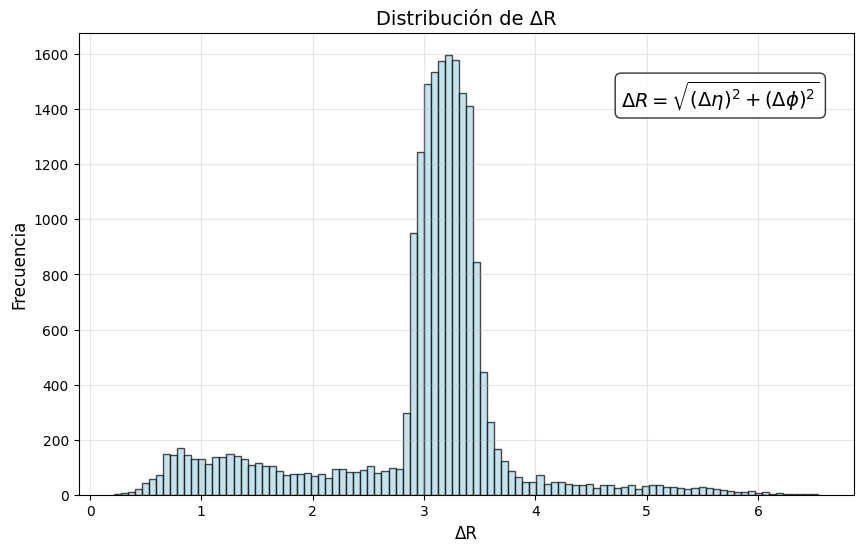

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calcular DeltaR (si no lo tienes)
carpeta['DeltaR'] = np.sqrt((carpeta['eta1'] - carpeta['eta2'])**2 +
                            (carpeta['phi1'] - carpeta['phi2'])**2)

# ============================================
# GRÁFICA DE ΔR CON SU ECUACIÓN
# ============================================
plt.figure(figsize=(10, 6))
plt.hist(carpeta['DeltaR'].dropna(), bins=100, color='lightblue', edgecolor='black', alpha=0.7)
plt.xlabel('ΔR', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de ΔR', fontsize=14)
plt.grid(True, alpha=0.3)

# Añadir la ecuación en la gráfica
ecuacion = r'$\Delta R = \sqrt{(\Delta \eta)^2 + (\Delta \phi)^2}$'
plt.text(0.7, 0.9, ecuacion, transform=plt.gca().transAxes,
         fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()

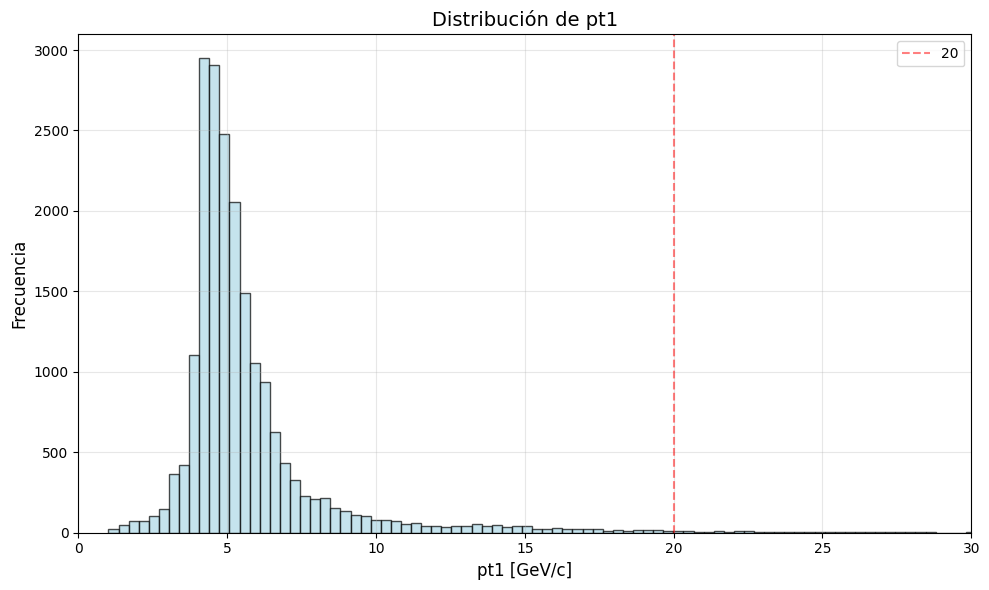

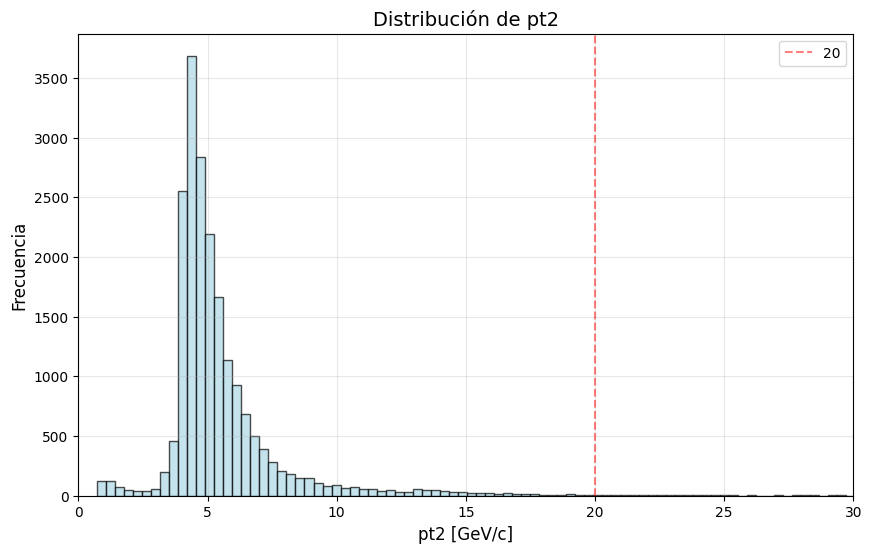

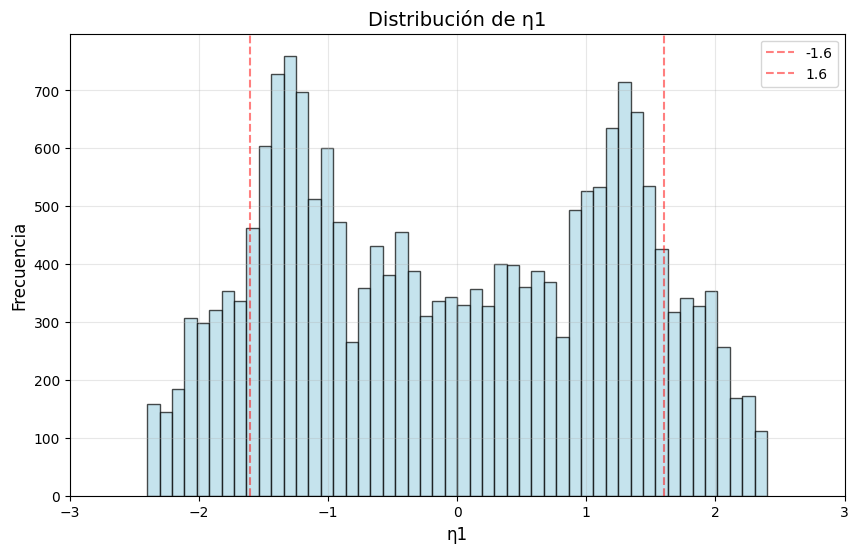

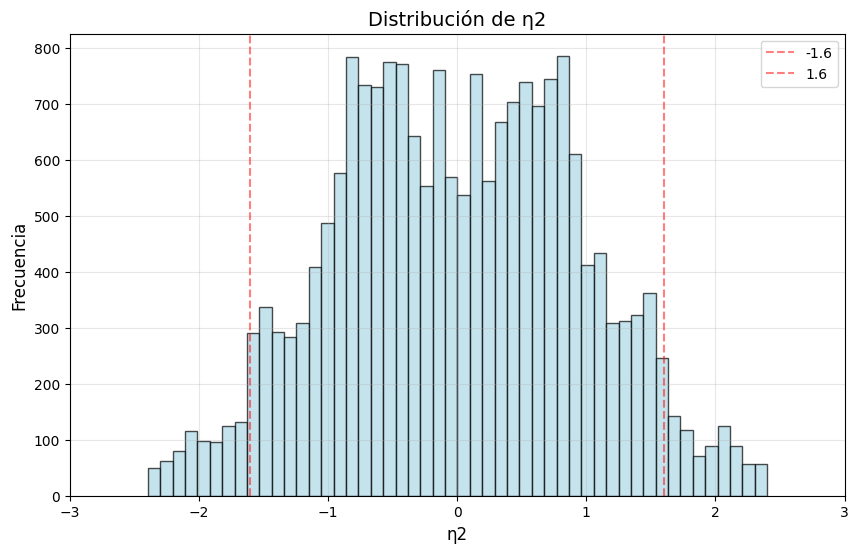

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# GRÁFICA 1: pt1
# ============================================
plt.figure(figsize=(10, 6))
plt.hist(carpeta['pt1'].dropna(), bins=400, color='lightblue', edgecolor='black', alpha=0.7)
plt.xlabel('pt1 [GeV/c]', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de pt1', fontsize=14)
plt.xlim(0, 30)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.axvline(x=20, color='red', linestyle='--', alpha=0.5, label='20')
plt.legend()
plt.show()

# ============================================
# GRÁFICA 2: pt2
# ============================================
plt.figure(figsize=(10, 6))
plt.hist(carpeta['pt2'].dropna(), bins=400, color='lightblue', edgecolor='black', alpha=0.7)
plt.xlabel('pt2 [GeV/c]', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de pt2', fontsize=14)
plt.xlim(0, 30)
plt.grid(True, alpha=0.3)
plt.axvline(x=20, color='red', linestyle='--', alpha=0.5, label='20')
plt.legend()
plt.show()

# ============================================
# GRÁFICA 3: eta1
# ============================================
plt.figure(figsize=(10, 6))
plt.hist(carpeta['eta1'].dropna(), bins=50, color='lightblue', edgecolor='black', alpha=0.7)
plt.xlabel('η1', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de η1', fontsize=14)
plt.xlim(-3, 3)
plt.grid(True, alpha=0.3)
plt.axvline(x=-1.6, color='red', linestyle='--', alpha=0.5, label='-1.6')
plt.axvline(x=1.6, color='red', linestyle='--', alpha=0.5, label='1.6')
plt.legend()

plt.show()

# ============================================
# GRÁFICA 4: eta2
# ============================================
plt.figure(figsize=(10, 6))
plt.hist(carpeta['eta2'].dropna(), bins=50, color='lightblue', edgecolor='black', alpha=0.7)
plt.xlabel('η2', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de η2', fontsize=14)
plt.xlim(-3, 3)
plt.grid(True, alpha=0.3)
plt.axvline(x=-1.6, color='red', linestyle='--', alpha=0.5, label='-1.6')
plt.axvline(x=1.6, color='red', linestyle='--', alpha=0.5, label='1.6')
plt.legend()

plt.show()

In [ ]:
total_inicial = len(carpeta)
print(f"\nTotal inicial de eventos: {total_inicial}")


#tipo de muón (Global Muon)
corte1 = (carpeta['type1'] == 'G') & (carpeta['type2'] == 'G')
carpeta_c1 = carpeta[corte1]
print(f"\nSolo muones Globales (type='G'):")
print(f"   Eventos restantes: {len(carpeta_c1)}")
print(f"   Eventos eliminados: {total_inicial - len(carpeta_c1)}")

#cargas opuestas
corte2 = (carpeta_c1['Q1'] * carpeta_c1['Q2'] == -1)
carpeta_c2 = carpeta_c1[corte2]
print(f"\nCargas opuestas (Q1*Q2 = -1):")
print(f"   Eventos restantes: {len(carpeta_c2)}")
print(f"   Eventos eliminados: {len(carpeta_c1) - len(carpeta_c2)}")

#momento transverso mínimo (pt < 20 GeV)
corte3 = (carpeta_c2['pt1'] < 20) & (carpeta_c2['pt2'] < 20)
carpeta_c3 = carpeta_c2[corte3]
print(f"\nPt < 20 GeV (ambos muones):")
print(f"   Eventos restantes: {len(carpeta_c3)}")
print(f"   Eventos eliminados: {len(carpeta_c2) - len(carpeta_c3)}")

#aceptancia del detector (|eta| < 1.6)
corte4 = (abs(carpeta_c3['eta1']) < 1.6) & (abs(carpeta_c3['eta2']) < 1.6)
carpeta_c4 = carpeta_c3[corte4]
print(f"\nAceptancia (|eta| < 1.6):")
print(f"   Eventos restantes: {len(carpeta_c4)}")
print(f"   Eventos eliminados: {len(carpeta_c3) - len(carpeta_c4)}")

carpeta_clean = carpeta_c4
print(f"\nTOTAL FINAL DE EVENTOS: {len(carpeta_clean)}")


Total inicial de eventos: 20000

Solo muones Globales (type='G'):
   Eventos restantes: 18881
   Eventos eliminados: 1119

Cargas opuestas (Q1*Q2 = -1):
   Eventos restantes: 18881
   Eventos eliminados: 0

Pt < 20 GeV (ambos muones):
   Eventos restantes: 18644
   Eventos eliminados: 237

Aceptancia (|eta| < 1.6):
   Eventos restantes: 14092
   Eventos eliminados: 4552

TOTAL FINAL DE EVENTOS: 14092


In [ ]:
import numpy as np

# Definir intervalos
intervalos = [(9.25, 9.75), (9.75, 10.25), (10.25, 10.75)]

print("PICOS DE MASA INVARIANTE:")
print("-" * 40)

for i, (inf, sup) in enumerate(intervalos, 1):
    # Seleccionar datos en el intervalo
    mask = (carpeta_clean['M'] >= inf) & (carpeta_clean['M'] <= sup)
    datos = carpeta_clean[mask]['M']

    if len(datos) > 0:
        # Crear histograma
        hist, bins = np.histogram(datos, bins=30)
        centro = (bins[:-1] + bins[1:]) / 2

        # Encontrar el pico (bin con más eventos)
        idx = np.argmax(hist)
        print(f"Pico {i}: {centro[idx]:.3f} GeV/c²")
    else:
        print(f"Pico {i}: No hay eventos")

print("-" * 40)

PICOS DE MASA INVARIANTE:
----------------------------------------
Pico 1: 9.458 GeV/c²
Pico 2: 9.992 GeV/c²
Pico 3: 10.358 GeV/c²
----------------------------------------


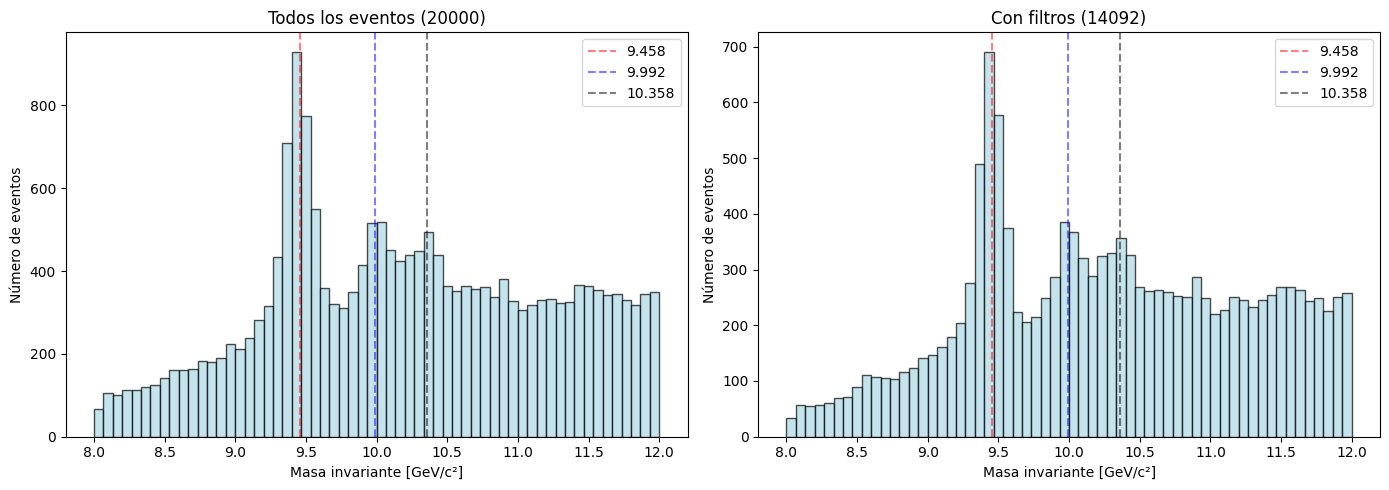

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(carpeta['M'], bins=60, range=(8, 12), color='lightblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Masa invariante [GeV/c²]')
ax1.set_ylabel('Número de eventos')
ax1.set_title(f'Todos los eventos ({len(carpeta)})')
ax1.axvline(x=9.458, color='red', linestyle='--', alpha=0.5, label='9.458')
ax1.axvline(x=9.992, color='blue', linestyle='--', alpha=0.5, label='9.992')
ax1.axvline(x=10.358, color='black', linestyle='--', alpha=0.5, label='10.358')
ax1.legend()

ax2.hist(carpeta_clean['M'], bins=60, range=(8, 12), color='lightblue', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Masa invariante [GeV/c²]')
ax2.set_ylabel('Número de eventos')
ax2.set_title(f'Con filtros ({len(carpeta_clean)})')
ax2.axvline(x=9.458, color='red', linestyle='--', alpha=0.5, label='9.458')
ax2.axvline(x=9.992, color='blue', linestyle='--', alpha=0.5, label='9.992')
ax2.axvline(x=10.358, color='black', linestyle='--', alpha=0.5, label='10.358')
ax2.legend()

plt.tight_layout()
plt.show()


Total inicial: 20000 eventos

Solo muones Globales (type='G'):
   Eventos restantes: 18881
   Eliminados: 1119

Cargas opuestas (Q1*Q2 = -1):
   Eventos restantes: 18881 
   Eliminados: 0

pt < 20 GeV (ambos muones):
   Eventos restantes: 18644
   Eliminados: 237

eta1 (-1.6 < eta1 < 1.6):
   Eventos restantes: 14392
   Eliminados: 4252

eta2 (-1.6 < eta2 < 1.6):
   Eventos restantes: 14092
   Eliminados: 300

Masa invariante (8 < M < 12 GeV):
   Eventos restantes: 14074
   Eliminados: 18

DeltaR (DeltaR <= 2):
   Eventos restantes: 1818
   Eliminados: 12256


MUESTRA FINAL: 1818 eventos


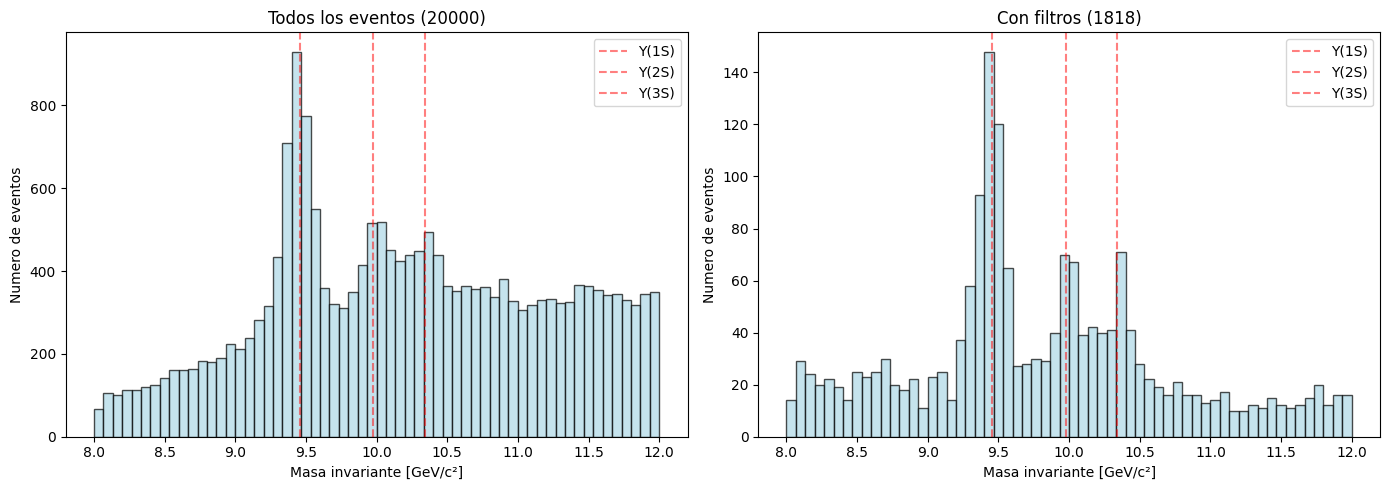

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#inicializar con todos los eventos
carpeta_paso = carpeta.copy()
total_inicial = len(carpeta_paso)
paso_anterior = total_inicial

print(f"\nTotal inicial: {total_inicial} eventos")

#tipo de muón (Global Muon)
corte1 = (carpeta_paso['type1'] == 'G') & (carpeta_paso['type2'] == 'G')
carpeta_paso = carpeta_paso[corte1]
print(f"\nSolo muones Globales (type='G'):")
print(f"   Eventos restantes: {len(carpeta_paso)}")
print(f"   Eliminados: {paso_anterior - len(carpeta_paso)}")
paso_anterior = len(carpeta_paso)

#cargas opuestas
corte2 = (carpeta_paso['Q1'] * carpeta_paso['Q2'] == -1)
carpeta_paso = carpeta_paso[corte2]
print(f"\nCargas opuestas (Q1*Q2 = -1):")
print(f"   Eventos restantes: {len(carpeta_paso)} ")
print(f"   Eliminados: {paso_anterior - len(carpeta_paso)}")
paso_anterior = len(carpeta_paso)

#momento transverso mínimo (pt < 20 GeV)
corte3 = (carpeta_paso['pt1'] < 20) & (carpeta_paso['pt2'] < 20)
carpeta_paso = carpeta_paso[corte3]
print(f"\npt < 20 GeV (ambos muones):")
print(f"   Eventos restantes: {len(carpeta_paso)}")
print(f"   Eliminados: {paso_anterior - len(carpeta_paso)}")
paso_anterior = len(carpeta_paso)

#eta1 entre -1.6 y 1.6
corte6 = (carpeta_paso['eta1'] > -1.6) & (carpeta_paso['eta1'] < 1.6)
carpeta_paso = carpeta_paso[corte6]
print(f"\neta1 (-1.6 < eta1 < 1.6):")
print(f"   Eventos restantes: {len(carpeta_paso)}")
print(f"   Eliminados: {paso_anterior - len(carpeta_paso)}")
paso_anterior = len(carpeta_paso)

#eta2 entre -1.6 y 1.6
corte7 = (carpeta_paso['eta2'] > -1.6) & (carpeta_paso['eta2'] < 1.6)
carpeta_paso = carpeta_paso[corte7]
print(f"\neta2 (-1.6 < eta2 < 1.6):")
print(f"   Eventos restantes: {len(carpeta_paso)}")
print(f"   Eliminados: {paso_anterior - len(carpeta_paso)}")
paso_anterior = len(carpeta_paso)

#masa invariante entre 8 y 12 GeV
corte5 = (carpeta_paso['M'] > 8) & (carpeta_paso['M'] < 12)
carpeta_paso = carpeta_paso[corte5]
print(f"\nMasa invariante (8 < M < 12 GeV):")
print(f"   Eventos restantes: {len(carpeta_paso)}")
print(f"   Eliminados: {paso_anterior - len(carpeta_paso)}")
paso_anterior = len(carpeta_paso)

#DeltaR <= 2
corte8 = (carpeta_paso['DeltaR'] <= 2)
carpeta_paso = carpeta_paso[corte8]
print(f"\nDeltaR (DeltaR <= 2):")
print(f"   Eventos restantes: {len(carpeta_paso)}")
print(f"   Eliminados: {paso_anterior - len(carpeta_paso)}")
paso_anterior = len(carpeta_paso)

#muestra final
carpeta_filtrada = carpeta_paso.copy()

print(f"\n\nMUESTRA FINAL: {len(carpeta_filtrada)} eventos")

# Grafica de comparacion antes/despues de la masa invariante
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(carpeta['M'], bins=60, range=(8, 12), color='lightblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Masa invariante [GeV/c²]')
ax1.set_ylabel('Numero de eventos')
ax1.set_title(f'Todos los eventos ({len(carpeta)})')
ax1.axvline(x=9.458, color='red', linestyle='--', alpha=0.5, label='Y(1S)')
ax1.axvline(x=9.976, color='red', linestyle='--', alpha=0.5, label='Y(2S)')
ax1.axvline(x=10.341, color='red', linestyle='--', alpha=0.5, label='Y(3S)')
ax1.legend()

ax2.hist(carpeta_filtrada['M'], bins=60, range=(8, 12), color='lightblue', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Masa invariante [GeV/c²]')
ax2.set_ylabel('Numero de eventos')
ax2.set_title(f'Con filtros ({len(carpeta_filtrada)})')
ax2.axvline(x=9.458, color='red', linestyle='--', alpha=0.5, label='Y(1S)')
ax2.axvline(x=9.976, color='red', linestyle='--', alpha=0.5, label='Y(2S)')
ax2.axvline(x=10.341, color='red', linestyle='--', alpha=0.5, label='Y(3S)')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Definir intervalos
intervalos = [(9.25, 9.75), (9.75, 10.25), (10.25, 10.75)]

print("PICOS DE MASA INVARIANTE:")
print("-" * 40)

for i, (inf, sup) in enumerate(intervalos, 1):
    # Seleccionar datos en el intervalo (usando carpeta_filtrada)
    mask = (carpeta_filtrada['M'] >= inf) & (carpeta_filtrada['M'] <= sup)
    datos = carpeta_filtrada[mask]['M']

    if len(datos) > 0:
        # Crear histograma
        hist, bins = np.histogram(datos, bins=30)
        centro = (bins[:-1] + bins[1:]) / 2

        # Encontrar el pico (bin con más eventos)
        idx = np.argmax(hist)
        print(f"Pico {i}: {centro[idx]:.3f} GeV/c²")
    else:
        print(f"Pico {i}: No hay eventos")

print("-" * 40)

PICOS DE MASA INVARIANTE:
----------------------------------------
Pico 1: 9.458 GeV/c²
Pico 2: 9.976 GeV/c²
Pico 3: 10.341 GeV/c²
----------------------------------------
